# **FASE C — Predicción de nuevos ejemplos**

## **Librerias**

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import timedelta
from tensorflow.keras.models import load_model

## **Cargar del modelo, escaladores y dataset**

Se carga el dataset final procesado y se asegura el orden temporal por `product_id` y `date`.
Luego, se cargan los mismos features utilizados durante el entrenamiento, junto con el modelo LSTM
y los escaladores específicos por producto.

Esto garantiza consistencia total entre el entrenamiento y la fase de predicción.

In [2]:
def load_artifacts():
    df = pd.read_csv("../data/processed/dataset_final.csv", parse_dates=["date"])
    df = df.sort_values(["product_id", "date"]).reset_index(drop=True)

    features = joblib.load("../models/features_lstm_optimo.save")
    model = load_model("../models/modelo_lstm_optimo.h5")
    scalers = joblib.load("../models/scalers_lstm_optimo.save")

    return df, features, model, scalers

df, features, model, scalers = load_artifacts()

print("Cargado correctamente!")

Cargado correctamente!


## **Función de predicción multi-paso**

Se implementa una función que genera predicciones a futuro para un producto específico.
La técnica usada es "multi-step autoregresiva": cada predicción futura se utiliza como entrada
del siguiente paso.

El procedimiento incluye:
- Seleccionar las últimas `seq_len` observaciones del producto.
- Escalar estos valores usando el scaler correspondiente.
- Generar predicciones repetitivas para `days_ahead` días.
- Desescalar los valores estimados para llevarlos nuevamente a unidades vendidas reales.

El resultado final es un DataFrame con las fechas futuras y las ventas estimadas.

In [3]:
SEQ_LEN=10
def predict_to_date(df, model, scalers, features, product_id, target_date):

    if product_id not in scalers:
        return {"error": "Producto no encontrado"}

    df_p = df[df["product_id"] == product_id].copy()
    df_p = df_p.sort_values("date")

    if len(df_p) < SEQ_LEN:
        return {"error": "Datos insuficientes"}

    scaler = scalers[product_id]

    recent = df_p[features].tail(SEQ_LEN).values
    input_seq = scaler.transform(recent)

    last_date = df_p["date"].max()
    target_date = pd.to_datetime(target_date)

    steps = (target_date - last_date).days

    if steps <= 0:
        return {"error": "Fecha debe ser futura"}

    pred = None
    for _ in range(steps):
        pred = model.predict(input_seq[np.newaxis, :, :], verbose=0)[0][0]
        new_row = input_seq[-1].copy()
        new_row[0] = pred
        input_seq = np.vstack([input_seq[1:], new_row])

    temp = np.zeros((1, len(features)))
    temp[0, 0] = pred
    pred_real = scaler.inverse_transform(temp)[0,0]

    return {
        "product_id": product_id,
        "target_date": target_date.strftime("%Y-%m-%d"),
        "pred_quantity_sold": round(float(pred_real), 2)
    }

In [4]:
def predict_all_for_date(df, model, scalers, features, target_date):

    results = []
    for pid in df["product_id"].unique():
        r = predict_to_date(df, model, scalers, features, pid, target_date)
        results.append(r)

    return pd.DataFrame(results)

## **Grafica histórica vs predicción**

Se grafica el comportamiento histórico reciente (últimos 60 días) junto con las predicciones
para los próximos días.

La línea histórica muestra el comportamiento real del producto.
La línea futura (generalmente más suave) representa la proyección estimada por el modelo.

Esta visualización permite identificar picos, tendencias y posibles caídas que requieran atención.

In [5]:
def plot_prediction(df_future, df_past):
    plt.figure(figsize=(10,5))
    plt.plot(df_past["date"].tail(60),
             df_past["quantity_sold"].tail(60),
             label="Histórico", linewidth=2)

    plt.plot(df_future["date"],
             df_future["pred_quantity_sold"],
             "--o", label="Predicción", color="orange")

    plt.title(f"Predicción futura - {df_future['product_id'].iloc[0]}")
    plt.xlabel("Fecha")
    plt.ylabel("Unidades vendidas")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# **Sistema de alertas**

Se define un umbral dinámico de alerta basado en:
- Media histórica del producto
- Desviación estándar de la serie

Se establecen tres niveles:
- OK: la predicción es normal.
- ADVERTENCIA: por debajo del 120% del umbral mínimo.
- CRÍTICO: por debajo del valor mínimo estimado.

Este esquema permite detectar automáticamente productos con riesgo de quiebre de stock.

A cada predicción futura se le asigna una categoría de alerta basada en el umbral calculado.
Esto permite diferenciar comportamientos normales de situaciones de riesgo.

El resultado final es un DataFrame enriquecido con la etiqueta:
- `OK`
- `ADVERTENCIA`
- `CRITICO`

In [6]:
def compute_thresholds(df_hist):
    mean = df_hist["quantity_sold"].mean()
    std = df_hist["quantity_sold"].std()

    critical = max(mean - std, 0)
    warning = critical * 1.2

    return critical, warning

def classify_alerts(df_future, df_hist):
    critical, warning = compute_thresholds(df_hist)

    df = df_future.copy()
    df["alert"] = "OK"
    df.loc[df["pred_quantity_sold"] <= warning, "alert"] = "ADVERTENCIA"
    df.loc[df["pred_quantity_sold"] <= critical, "alert"] = "CRITICO"

    return df, critical, warning

def evaluate_alert(pred_value, critical, warning):
    """
    Evalúa una predicción individual y retorna su estado.
    """
    if pred_value <= critical:
        return "CRITICO"
    elif pred_value <= warning:
        return "ADVERTENCIA"
    return "OK"

# **Prediccion para multiples productos**

Se genera una rutina que procesa una lista completa de productos, produciendo para cada uno:
- La predicción mínima en el horizonte
- La alerta final alcanzada
- Su threshold y nivel de advertencia

Este resumen permite comparar rápidamente el estado de toda la cartera de productos.

In [7]:
def predict_all_products(df, model, scalers, features, days_ahead=30):

    summaries = []
    product_ids = df["product_id"].unique()

    for pid in product_ids:
        past = df[df["product_id"] == pid]
        future = predict_to_date(df, model, scalers, features, pid, days_ahead)
        future, c, w = classify_alerts(future, past)

        summaries.append({
            "product_id": pid,
            "min_pred": future["pred_quantity_sold"].min(),
            "final_alert": future["alert"].iloc[-1],
            "critical_threshold": c,
            "warning_threshold": w
        })

    return pd.DataFrame(summaries)

## **Evolución diaria de alertas futuras (crítico / advertencia / ok)**

Esta visualización representa, día por día, el nivel de alerta estimado.
Cada punto corresponde a la predicción de demanda de un día futuro:

- **Verde**: comportamiento normal  
- **Naranja**: alerta temprana  
- **Rojo**: riesgo crítico

Permite detectar rápidamente si el producto tenderá a disminuir su demanda
o mantenerse en un rango saludable.

In [8]:
# --- 1. Definir función de gráfica (primero) ---
def plot_alert_timeline(df_future):
    color_map = {
        "OK": "green",
        "ADVERTENCIA": "orange",
        "CRITICO": "red"
    }

    plt.figure(figsize=(12,3))
    plt.scatter(
        df_future["date"],
        [1]*len(df_future),
        c=df_future["alert"].map(color_map),
        s=120
    )

    plt.yticks([])
    plt.title("Línea temporal de alertas futuras")
    plt.xlabel("Fecha")
    plt.grid(True, axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

product_id = "P001M"
tarjet_date = "2025-10-25"

result = predict_to_date(
    df, model, scalers, features,
    product_id="P001M",
    target_date="2025-10-25"
)

print(result)

/Users/andresmorocho/Downloads/Aprendizaje Automatico/Proyecto/venv/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


{'product_id': 'P001M', 'target_date': '2025-10-25', 'pred_quantity_sold': 76.92}


## **Estado final de todos los productos (gráfico global)**

Este gráfico resume el estado futuro de todos los productos analizados.
Cada barra representa la predicción mínima del horizonte de 30 días:

- **Verde**: demanda estable  
- **Naranja**: valor bajo que requiere monitoreo  
- **Rojo**: riesgo crítico según el umbral calculado  

Ofrece una visión general inmediata del inventario y permite priorizar acciones.

In [9]:
def plot_prediction(history_df, future_df):
    # Detectar nombre de columna de fecha en future_df
    date_col = "date" if "date" in future_df.columns else "target_date"

    plt.figure(figsize=(10,5))
    plt.plot(history_df["date"].tail(60),
             history_df["quantity_sold"].tail(60),
             label="Histórico")

    plt.scatter(future_df[date_col],
                future_df["pred_quantity_sold"],
                label="Predicción", color="orange")

    plt.legend()
    plt.grid()
    plt.show()

# **Pruebas de un solo producto en una fecha**

In [10]:
# ============================
# PRUEBA 1: Producto individual
# ============================

product_test = df["product_id"].iloc[0]
fecha_test = "2024-12-15"  # ejemplo

resultado = predict_to_date(
    df=df,
    model=model,
    scalers=scalers,
    features=features,
    product_id=product_test,
    target_date=fecha_test
)

print("\nRESULTADO PREDICCIÓN ÚNICA:")
display(resultado)

/Users/andresmorocho/Downloads/Aprendizaje Automatico/Proyecto/venv/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(



RESULTADO PREDICCIÓN ÚNICA:


{'product_id': 'P001M',
 'target_date': '2024-12-15',
 'pred_quantity_sold': 76.92}

# **Prediccion de TODOS los productos para una fecha**

In [11]:
# ============================
# PRUEBA 2: Todos los productos
# ============================

fecha_batch = "2024-12-15"

df_all = predict_all_for_date(
    df=df,
    model=model,
    scalers=scalers,
    features=features,
    target_date=fecha_batch
)

print("\nRESULTADO PREDICCIÓN PARA TODOS LOS PRODUCTOS:")
display(df_all)

/Users/andresmorocho/Downloads/Aprendizaje Automatico/Proyecto/venv/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/Users/andresmorocho/Downloads/Aprendizaje Automatico/Proyecto/venv/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/Users/andresmorocho/Downloads/Aprendizaje Automatico/Proyecto/venv/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/Users/andresmorocho/Downloads/Aprendizaje Automatico/Proyecto/venv/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/Users/andresmorocho/Downloads/Aprendizaje Automatico/Proyecto/venv/lib/


RESULTADO PREDICCIÓN PARA TODOS LOS PRODUCTOS:


,product_id,target_date,pred_quantity_sold
0,P001M,2024-12-15,76.92
1,P002B,2024-12-15,75.51
2,P003N,2024-12-15,83.38
3,P004T,2024-12-15,69.94
4,P005L,2024-12-15,63.39
5,P006Z,2024-12-15,75.28


# **Alertas integradas automaticamente**

In [12]:
# ============================
# PRUEBA 3: Evaluación de alertas
# ============================

alerts_results = []

for _, row in df_all.iterrows():
    pid = row["product_id"]
    pred = row["pred_quantity_sold"]

    df_hist = df[df["product_id"] == pid]

    critical, warning = compute_thresholds(df_hist)

    if pred <= critical:
        estado = "CRITICO"
    elif pred <= warning:
        estado = "ADVERTENCIA"
    else:
        estado = "OK"

    alerts_results.append({
        "product_id": pid,
        "fecha": fecha_batch,
        "predicción": round(pred, 2),
        "estado": estado
    })

df_alerts = pd.DataFrame(alerts_results)
display(df_alerts)

,product_id,fecha,predicción,estado
0,P001M,2024-12-15,76.92,OK
1,P002B,2024-12-15,75.51,OK
2,P003N,2024-12-15,83.38,OK
3,P004T,2024-12-15,69.94,ADVERTENCIA
4,P005L,2024-12-15,63.39,ADVERTENCIA
5,P006Z,2024-12-15,75.28,OK


# **Graficas Integradas**

**Histórico vs predicción puntual**

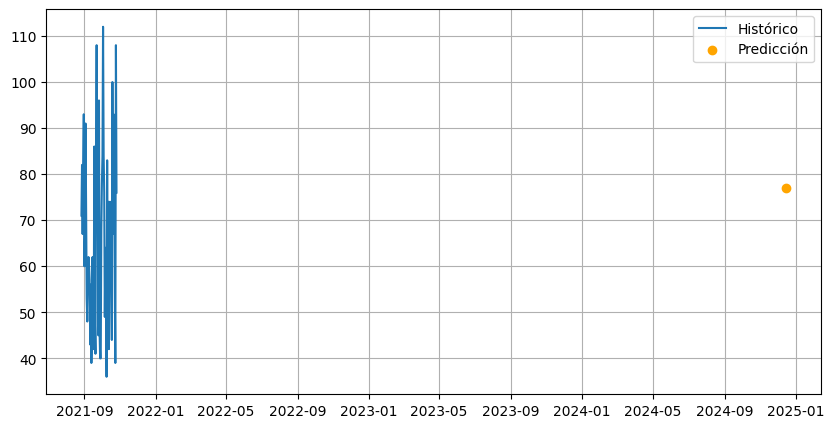

In [13]:
df_hist = df[df["product_id"] == product_test]
plot_prediction(df_hist, df_all[df_all["product_id"] == product_test])

In [14]:
assert "product_id" in resultado
assert "pred_quantity_sold" in resultado
assert isinstance(resultado["pred_quantity_sold"], float)

In [15]:
assert not df_all.empty
assert "product_id" in df_all.columns